In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import math
from scipy.optimize import minimize

In [2]:
# Define parameters for the simulation
SCREEN_WIDTH_CM = 50  # Width of the screen in centimeters
SCREEN_HEIGHT_CM = 30  # Height of the screen in centimeters
SENSOR_ANGLE_DEG = 30  # Angle of each HC-SR04 sensor in degrees
NUM_SENSORS = 3  # Number of sensors
SENSOR_MAX_RANGE_CM = 400  # Maximum range of HC-SR04 sensor in cm
SENSOR_MIN_RANGE_CM = 2  # Minimum range of HC-SR04 sensor in cm
SENSOR_NOISE_CM = 0.3  # Standard deviation of sensor noise in cm
OUTLIER_PROBABILITY = 0.02  # Probability of an outlier measurement
REFRESH_RATE_HZ = 10  # Default refresh rate in Hz

In [3]:
# Sensor positions (in cm) - positioned at top edge to cover a flat screen below them
# Sensors are arranged to cover 90 degrees (30+30+30)
sensor_positions = [
    [0, 0],  # Top-left corner
    [SCREEN_WIDTH_CM/2, 0],  # Top-middle
    [SCREEN_WIDTH_CM, 0]  # Top-right corner
]

# Sensor orientations in degrees (0 is straight down, negative is left, positive is right)
sensor_orientations = [-30, 0, 30]  # Each sensor points 30 degrees from vertical

In [4]:
# Class to model HC-SR04 ultrasonic sensor
class UltrasonicSensor:
    def __init__(self, position, orientation_deg, angle_deg, min_range_cm, max_range_cm, noise_cm):
        self.position = np.array(position)
        self.orientation_rad = np.radians(orientation_deg)
        self.angle_rad = np.radians(angle_deg)
        self.min_range_cm = min_range_cm
        self.max_range_cm = max_range_cm
        self.noise_cm = noise_cm
        
    def measure_distance(self, target_position):
        """Measure distance to target if it's within the sensor's detection cone"""
        target = np.array(target_position)
        
        # Vector from sensor to target
        direction = target - self.position
        distance = np.linalg.norm(direction)
        
        # If target is too close or too far, sensor can't detect it
        if distance < self.min_range_cm or distance > self.max_range_cm:
            return None
        
        # Calculate angle between sensor orientation and target
        if distance == 0:
            return None
            
        direction_normalized = direction / distance
        sensor_vector = np.array([np.sin(self.orientation_rad), np.cos(self.orientation_rad)])
        cos_angle = np.dot(direction_normalized, sensor_vector)
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        
        # Check if target is within sensor's detection cone
        if abs(angle) <= self.angle_rad / 2:
            # Add realistic noise to the measurement
            if np.random.random() < OUTLIER_PROBABILITY:
                # Generate an outlier
                noise = np.random.uniform(-10, 10)
            else:
                # Generate normal noise
                noise = np.random.normal(0, self.noise_cm)
            
            # Return the noisy distance measurement
            return distance + noise
        else:
            return None

In [5]:
# Initialize sensors
sensors = []
for i in range(NUM_SENSORS):
    sensors.append(UltrasonicSensor(
        position=sensor_positions[i],
        orientation_deg=sensor_orientations[i],
        angle_deg=SENSOR_ANGLE_DEG,
        min_range_cm=SENSOR_MIN_RANGE_CM,
        max_range_cm=SENSOR_MAX_RANGE_CM,
        noise_cm=SENSOR_NOISE_CM
    ))

In [6]:
def triangulate_position(distances):
    """
    Triangulate position based on distances from sensors
    Returns the estimated position as [x, y] in cm
    """
    if sum(d is not None for d in distances) < 2:
        return None  # Need at least 2 valid measurements
    
    # Define error function to minimize
    def error_function(pos):
        x, y = pos
        error = 0
        for i, d in enumerate(distances):
            if d is not None:
                sensor_pos = sensor_positions[i]
                expected_d = np.sqrt((x - sensor_pos[0])**2 + (y - sensor_pos[1])**2)
                error += (expected_d - d)**2
        return error
    
    # Initial guess: center of the screen
    initial_guess = [SCREEN_WIDTH_CM/2, SCREEN_HEIGHT_CM/2]
    
    # Minimize the error function
    result = minimize(error_function, initial_guess, method='L-BFGS-B',
                    bounds=[(0, SCREEN_WIDTH_CM), (0, SCREEN_HEIGHT_CM)])
    
    if result.success:
        return result.x
    else:
        return None

In [7]:
def kalman_filter(measurement, prev_state, prev_covariance):
    """
    Apply Kalman filtering to smooth position estimates
    """
    # System matrices
    A = np.eye(2)  # State transition matrix (identity for position only model)
    H = np.eye(2)  # Measurement matrix (direct observation of state)
    
    # Noise covariances
    Q = np.eye(2) * 0.1  # Process noise covariance
    R = np.eye(2) * 1.0  # Measurement noise covariance
    
    # Prediction step
    predicted_state = A @ prev_state
    predicted_covariance = A @ prev_covariance @ A.T + Q
    
    # Update step
    innovation = measurement - H @ predicted_state
    innovation_covariance = H @ predicted_covariance @ H.T + R
    kalman_gain = predicted_covariance @ H.T @ np.linalg.inv(innovation_covariance)
    
    updated_state = predicted_state + kalman_gain @ innovation
    updated_covariance = (np.eye(2) - kalman_gain @ H) @ predicted_covariance
    
    return updated_state, updated_covariance

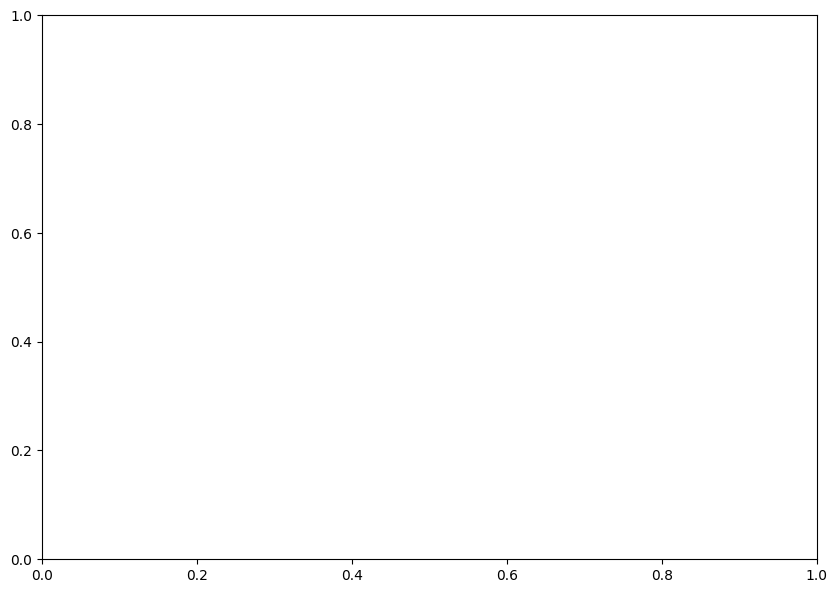

In [8]:
# Set up the interactive plot
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(bottom=0.2)

In [9]:
# Function to update the plot based on cursor position
def update_plot(event):
    if event.inaxes != ax:
        return
    
    ax.clear()
    
    # Convert from plot coordinates to cm
    x_cm = event.xdata
    y_cm = event.ydata
    
    # Set the simulated finger position
    finger_position = [x_cm, y_cm]
    
    # Get sensor measurements
    measurements = []
    for sensor in sensors:
        distance = sensor.measure_distance(finger_position)
        measurements.append(distance)
    
    # Triangulate position based on measurements
    estimated_position = triangulate_position(measurements)
    
    # Draw the screen boundaries
    ax.set_xlim(0, SCREEN_WIDTH_CM)
    ax.set_ylim(0, SCREEN_HEIGHT_CM)
    ax.set_xlabel('Width (cm)')
    ax.set_ylabel('Height (cm)')
    ax.set_title('HC-SR04 Sensor Fusion Simulation')
    
    # Draw the sensors and their detection cones
    for i, sensor in enumerate(sensors):
        ax.plot(sensor.position[0], sensor.position[1], 'bs', markersize=10, label=f'Sensor {i+1}')
        
        # Draw detection cone
        cone_angle = sensor.angle_rad / 2
        orientation = sensor.orientation_rad
        angles = np.linspace(orientation - cone_angle, orientation + cone_angle, 50)
        cone_x = sensor.position[0] + np.sin(angles) * SENSOR_MAX_RANGE_CM
        cone_y = sensor.position[1] + np.cos(angles) * SENSOR_MAX_RANGE_CM
        ax.fill(np.append(sensor.position[0], cone_x), np.append(sensor.position[1], cone_y), 
                alpha=0.1, color='blue')
        
        # Draw measurement line if available
        if measurements[i] is not None:
            direction = np.array([np.sin(orientation), np.cos(orientation)])
            endpoint = sensor.position + direction * measurements[i]
            ax.plot([sensor.position[0], endpoint[0]], [sensor.position[1], endpoint[1]], 
                    'g--', alpha=0.5)
    
    # Draw actual finger position
    ax.plot(finger_position[0], finger_position[1], 'ro', markersize=8, label='Actual Position')
    
    # Draw estimated position if available
    if estimated_position is not None:
        ax.plot(estimated_position[0], estimated_position[1], 'go', markersize=8, label='Estimated Position')
        
        # Display measurement data
        info_text = (f"Actual: ({finger_position[0]:.2f}, {finger_position[1]:.2f}) cm\n"
                    f"Estimated: ({estimated_position[0]:.2f}, {estimated_position[1]:.2f}) cm\n"
                    f"Error: {np.linalg.norm(np.array(finger_position) - estimated_position):.2f} cm\n"
                    f"Sensors: {[f'{d:.2f}' if d is not None else 'None' for d in measurements]}")
    else:
        info_text = "Insufficient sensor data for position estimation"
    
    ax.text(0.02, 0.02, info_text, transform=ax.transAxes, bbox=dict(facecolor='white', alpha=0.7))
    
    # Show mouse click status
    if hasattr(event, 'button') and event.button == 1:  # Left click
        ax.text(0.5, 0.95, "TOUCH DETECTED!", transform=ax.transAxes, 
                horizontalalignment='center', color='red', fontsize=14,
                bbox=dict(facecolor='white', alpha=0.7))
    
    ax.legend()
    plt.draw()

In [10]:
# Connect events to the figure
cid_motion = fig.canvas.mpl_connect('motion_notify_event', update_plot)
cid_click = fig.canvas.mpl_connect('button_press_event', update_plot)
cid_release = fig.canvas.mpl_connect('button_release_event', update_plot)

# Refresh rate control
refresh_rate_slider = widgets.FloatSlider(
    value=REFRESH_RATE_HZ,
    min=1,
    max=30,
    step=1,
    description='Refresh Rate (Hz):',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.0f',
)



In [11]:
# Display the slider
display(refresh_rate_slider)

# Set up the plot for interactive use with a specific refresh rate
plt.show()

# Function to implement custom refresh rate control
def set_refresh_rate(change):
    global REFRESH_RATE_HZ
    REFRESH_RATE_HZ = change['new']
    # Note: In a Jupyter notebook, matplotlib's interactive mode doesn't directly
    # support custom refresh rates. In a real implementation, you would use
    # a proper animation loop with a specific interval.

refresh_rate_slider.observe(set_refresh_rate, names='value')

# Additional information
print("""
Simulation Controls:
- Move your mouse cursor over the plot area to simulate finger hovering
- Click to simulate finger touching the surface
- Adjust the slider to change the refresh rate
- The green dashed lines show detected distances from each sensor
- Blue areas represent the sensor detection cones (30° each)
- The error is calculated as Euclidean distance between actual and estimated positions
""")


FloatSlider(value=10.0, description='Refresh Rate (Hz):', max=30.0, min=1.0, readout_format='.0f', step=1.0)


Simulation Controls:
- Move your mouse cursor over the plot area to simulate finger hovering
- Click to simulate finger touching the surface
- Adjust the slider to change the refresh rate
- The green dashed lines show detected distances from each sensor
- Blue areas represent the sensor detection cones (30° each)
- The error is calculated as Euclidean distance between actual and estimated positions



In [12]:
# Log data for analysis
position_log = []

def log_position(event):
    if event.inaxes != ax:
        return
    
    # Convert from plot coordinates to cm
    x_cm = event.xdata
    y_cm = event.ydata
    
    # Set the simulated finger position
    finger_position = [x_cm, y_cm]
    
    # Get sensor measurements
    measurements = []
    for sensor in sensors:
        distance = sensor.measure_distance(finger_position)
        measurements.append(distance)
    
    # Triangulate position based on measurements
    estimated_position = triangulate_position(measurements)
    
    # Log data
    position_log.append({
        'timestamp': time.time(),
        'actual': finger_position,
        'estimated': estimated_position if estimated_position is not None else [None, None],
        'measurements': measurements,
        'click': hasattr(event, 'button') and event.button == 1
    })

# Connect the logging function
cid_log = fig.canvas.mpl_connect('motion_notify_event', log_position)
cid_click_log = fig.canvas.mpl_connect('button_press_event', log_position) 


Ultrasonic Sensor Interaction Bridge loaded.
To use with simulation.py, add these lines after creating update_plot:

from python_bridge import register_interaction_bridge
update_plot = register_interaction_bridge(update_plot)

This will automatically send position data to the Node.js API.
Make sure the API server (api.js) is running first.



Connected to Node.js API server


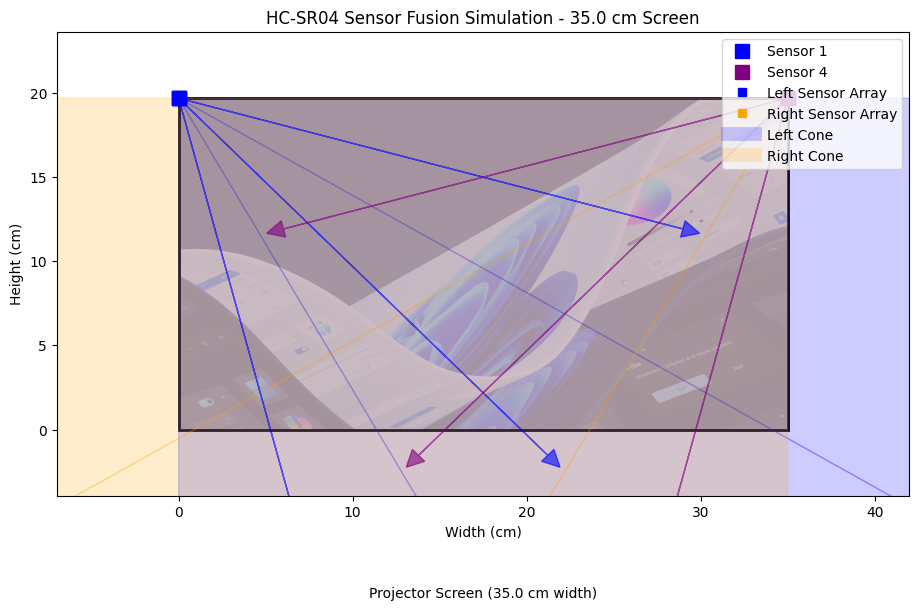


Enhanced Simulation Controls with Configurable Sensors:

Sensor Configuration:
- Use the 'Presets' dropdown to quickly apply common sensor configurations
- Adjust the 'Angle Width' slider to change the detection cone width for all sensors
- Use the tabs to adjust individual sensor orientation angles
- 'Reset to Defaults' button restores the original configuration

Sensor Orientation Guide:
- 90° points straight down from the top
- Values <90° point toward the right
- Values >90° point toward the left
- Green cones represent sensors pointing toward the center
- Orange cones represent sensors covering extended areas

Usage:
- Move your mouse cursor over the plot area to simulate finger hovering
- Click to simulate finger touching the surface
- The finger orientation is calculated based on recent movement history
- "OUT OF BOUNDS" is displayed when the finger is outside the screen area



Button(button_style='info', description='Analyze Logs', style=ButtonStyle(), tooltip='Analyze the logged posit…

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import math
from scipy.optimize import minimize
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg
import os
from PIL import Image
from io import BytesIO
import requests

from python_bridge import register_interaction_bridge

# Define parameters for the simulation
SCREEN_WIDTH_CM = round(16 * (15.6 * 2.54) / np.sqrt(16**2 + 9**2), 0)  # 15.6-inch diagonal to width in cm for a 16:9 screen
SCREEN_HEIGHT_CM = (SCREEN_WIDTH_CM * 9/16)  # Height of the screen (assuming 16:9 aspect ratio)
NUM_SENSORS_PER_ARRAY = 3  # Number of sensors per array (2 arrays)
SENSOR_MAX_RANGE_CM = 400  # Maximum range of HC-SR04 sensor in cm
SENSOR_MIN_RANGE_CM = 2  # Minimum range of HC-SR04 sensor in cm
SENSOR_NOISE_CM = 0.3  # Standard deviation of sensor noise in cm
OUTLIER_PROBABILITY = 0.02  # Probability of an outlier measurement
REFRESH_RATE_HZ = 60  # Default refresh rate in Hz
FINGER_LENGTH_CM = SCREEN_WIDTH_CM/20  # Length of the finger visualization in cm

# Default sensor angles - will be configurable via sliders
sensor_angle_cone_threshold = 30  # Threshold of each sensors's detection cone in degrees

# Default sensor orientations in degrees (configurable)
# 90° is straight down, <90° is left-down, >90° is right-down
default_sensor_orientations = [
    # First array (top-left) - covers left side
    -15,-45,-75,
    
    # Second array (top-right) - covers right side
    -105, -135, -165
]

# Sensor positions (in cm) - two arrays of 3 sensors each
sensor_positions = [
    # First array (top-left corner)
    [0, SCREEN_HEIGHT_CM], [0, SCREEN_HEIGHT_CM], [0, SCREEN_HEIGHT_CM],
    
    # Second array (top-right corner)
    [SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM], [SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM], [SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM]
]

# Class to model HC-SR04 ultrasonic sensor
class UltrasonicSensor:
    def __init__(self, position, orientation_deg, angle_deg, min_range_cm, max_range_cm, noise_cm):
        self.position = np.array(position)
        self.orientation_rad = np.radians(orientation_deg)
        self.angle_rad = np.radians(angle_deg)
        self.min_range_cm = min_range_cm
        self.max_range_cm = max_range_cm
        self.noise_cm = noise_cm
        
    def measure_distance(self, target_position):
        """Measure distance to target if it's within the sensor's detection cone"""
        target = np.array(target_position)
        
        # Vector from sensor to target
        direction = target - self.position
        distance = np.linalg.norm(direction)
        
        # If target is too close or too far, sensor can't detect it
        if distance < self.min_range_cm or distance > self.max_range_cm:
            return None
        
        # Calculate angle between sensor orientation and target
        if distance == 0:
            return None
            
        direction_normalized = direction / distance
        # For top-mounted sensors, use proper vector calculation based on orientation
        sensor_vector = np.array([np.cos(self.orientation_rad), np.sin(self.orientation_rad)])
        cos_angle = np.dot(direction_normalized, sensor_vector)
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        
        # Check if target is within sensor's detection cone
        if abs(angle) <= self.angle_rad / 2:
            # Add realistic noise to the measurement
            if np.random.random() < OUTLIER_PROBABILITY:
                # Generate an outlier
                noise = np.random.uniform(-10, 10)
            else:
                # Generate normal noise
                noise = np.random.normal(0, self.noise_cm)
            
            # Return the noisy distance measurement
            return distance + noise
        else:
            return None

# Function to initialize sensors with current orientation settings
def initialize_sensors(orientations, angle_width):
    sensors = []
    for i in range(NUM_SENSORS_PER_ARRAY * 2):
        sensors.append(UltrasonicSensor(
            position=sensor_positions[i],
            orientation_deg=orientations[i],
            angle_deg=angle_width,
            min_range_cm=SENSOR_MIN_RANGE_CM,
            max_range_cm=SENSOR_MAX_RANGE_CM,
            noise_cm=SENSOR_NOISE_CM
        ))
    return sensors

# Initialize sensors with default values
current_sensor_orientations = default_sensor_orientations.copy()
current_sensor_angle_deg = sensor_angle_cone_threshold
sensors = initialize_sensors(current_sensor_orientations, current_sensor_angle_deg)

def triangulate_position(distances):
    """
    Triangulate position based on distances from sensors
    Returns the estimated position as [x, y] in cm
    """
    if sum(d is not None for d in distances) < 2:
        return None  # Need at least 2 valid measurements
    
    # Define error function to minimize
    def error_function(pos):
        x, y = pos
        error = 0
        for i, d in enumerate(distances):
            if d is not None:
                sensor_pos = sensor_positions[i]
                expected_d = np.sqrt((x - sensor_pos[0])**2 + (y - sensor_pos[1])**2)
                error += (expected_d - d)**2
        return error
    
    # Initial guess: center of the screen
    initial_guess = [SCREEN_WIDTH_CM/2, SCREEN_HEIGHT_CM/2]
    
    # Minimize the error function
    result = minimize(error_function, initial_guess, method='L-BFGS-B',
                    bounds=[(0, SCREEN_WIDTH_CM*1.5), (0, SCREEN_HEIGHT_CM*1.5)])
    
    if result.success:
        return result.x
    else:
        return None

# Function to calculate finger angle based on movement history
def calculate_finger_angle(position, prev_positions, window_size=5):
    """Calculate finger angle based on recent movement history"""
    if len(prev_positions) < window_size:
        return 0  # Default angle if not enough history
    
    # Use the most recent positions for calculation
    recent_positions = prev_positions[-window_size:]
    
    # Calculate movement vector
    if all(p is not None for p in recent_positions):
        # Create arrays for x and y coordinates
        x_coords = [p[0] for p in recent_positions]
        y_coords = [p[1] for p in recent_positions]
        
        # Use linear regression to find direction
        n = len(recent_positions)
        x_mean = sum(x_coords) / n
        y_mean = sum(y_coords) / n
        
        # Calculate slope using least squares
        numerator = sum((x_coords[i] - x_mean) * (y_coords[i] - y_mean) for i in range(n))
        denominator = sum((x_coords[i] - x_mean) ** 2 for i in range(n))
        
        if abs(denominator) > 1e-10:  # Avoid division by zero
            slope = numerator / denominator
            angle_rad = math.atan(slope)
            return math.degrees(angle_rad)
        
    return 0  # Default angle if calculation fails

# Get screen background
screen_background = Image.open("Z:\Media\Pictures\Saved Pictures\WIP-9th-anniversary-wallpaper-dark (Custom).png")

# Set up the interactive plot
fig, ax = plt.subplots(figsize=(11, 8))
plt.subplots_adjust(bottom=0.3)  # Make more space for controls

# Previous positions for angle calculation
prev_estimated_positions = []
# Add a global variable for throttling refresh rate
last_update_time = 0

# Function to update the plot based on cursor position
def update_plot(event=None):
    global last_update_time, REFRESH_RATE_HZ
    current_time = time.time()
    if current_time - last_update_time < 1.0/REFRESH_RATE_HZ:
        return  # Throttle update based on refresh rate
    last_update_time = current_time
    if event is not None and event.inaxes != ax:
        return
    
    ax.clear()
    
    # Handle event data if provided (mouse movement)
    if event is not None:
        # Convert from plot coordinates to cm
        x_cm = event.xdata
        y_cm = event.ydata
        
        # Set the simulated finger position
        finger_position = [x_cm, y_cm]
        
        # Get sensor measurements
        measurements = []
        for sensor in sensors:
            distance = sensor.measure_distance(finger_position)
            measurements.append(distance)
        
        # Triangulate position based on measurements
        estimated_position = triangulate_position(measurements)
        
        # Update position history for angle calculation
        if estimated_position is not None:
            prev_estimated_positions.append(estimated_position)
            if len(prev_estimated_positions) > 20:  # Keep last 20 positions
                prev_estimated_positions.pop(0)
        
        # Calculate finger angle
        finger_angle = calculate_finger_angle(finger_position, prev_estimated_positions) if estimated_position is not None else 0
    else:
        # Default values when just updating sensor configurations
        finger_position = [SCREEN_WIDTH_CM/2, SCREEN_HEIGHT_CM/2]
        measurements = [None] * len(sensors)
        estimated_position = None
        finger_angle = 0
    
    # Draw the screen boundaries
    ax.set_xlim(-SCREEN_WIDTH_CM/5, SCREEN_WIDTH_CM*1.2)
    ax.set_ylim(-SCREEN_HEIGHT_CM/5, SCREEN_HEIGHT_CM*1.2)
    ax.set_xlabel('Width (cm)')
    ax.set_ylabel('Height (cm)')
    ax.set_title(f'HC-SR04 Sensor Fusion Simulation - {SCREEN_WIDTH_CM} cm Screen')
    
    # Draw the projector screen
    if screen_background is not None:
        # Display the background image
        img_extent = [0, SCREEN_WIDTH_CM, 0, SCREEN_HEIGHT_CM]
        ax.imshow(np.asarray(screen_background), extent=img_extent, alpha=0.3, aspect='auto')
    
    # Draw screen border
    screen_rect = Rectangle((0, 0), SCREEN_WIDTH_CM, SCREEN_HEIGHT_CM, linewidth=2, 
                              edgecolor='black', facecolor='none')
    ax.add_patch(screen_rect)
    ax.text(SCREEN_WIDTH_CM/2, -10, f"Projector Screen ({SCREEN_WIDTH_CM} cm width)", ha='center')
    
    # Draw the sensors and their detection cones
    for i, sensor in enumerate(sensors):
        marker_color = 'blue' if i < NUM_SENSORS_PER_ARRAY else 'purple'
        ax.plot(sensor.position[0], sensor.position[1], 's', color=marker_color, 
                markersize=10, label=f'Sensor {i+1}' if i == 0 or i == NUM_SENSORS_PER_ARRAY else "")
        
        # Draw detection cone - updated for top-mounted sensors
        cone_angle = sensor.angle_rad / 2
        orientation = sensor.orientation_rad
        angles = np.linspace(orientation - cone_angle, orientation + cone_angle, 50)
        
        # For top-mounted sensors, convert to cartesian coordinates correctly
        cone_x = sensor.position[0] + np.cos(angles) * SENSOR_MAX_RANGE_CM
        cone_y = sensor.position[1] + np.sin(angles) * SENSOR_MAX_RANGE_CM
        
        # Set colors based on sensor group: blue for left sensors, orange for right sensors.
        if i < NUM_SENSORS_PER_ARRAY:
            cone_color = 'blue'
            cone_alpha = 0.2
        else:
            cone_color = 'orange'
            cone_alpha = 0.2
            
        ax.fill(np.append(sensor.position[0], cone_x), np.append(sensor.position[1], cone_y), 
                alpha=cone_alpha, color=cone_color)
        
        # Draw measurement line if available and event is provided
        if event is not None and measurements[i] is not None:
            direction = np.array([np.cos(orientation), np.sin(orientation)])
            endpoint = sensor.position + direction * measurements[i]
            ax.plot([sensor.position[0], endpoint[0]], [sensor.position[1], endpoint[1]], 
                    'g--', alpha=0.5)
    
    # Show directional arrows for each sensor
    arrow_length = 30
    for i, sensor in enumerate(sensors):
        orientation_rad = np.radians(current_sensor_orientations[i])
        ax.arrow(sensor.position[0], sensor.position[1], 
                 arrow_length * np.cos(orientation_rad), arrow_length * np.sin(orientation_rad), 
                 head_width=1, head_length=1, 
                 fc='blue' if i < NUM_SENSORS_PER_ARRAY else 'purple', 
                 ec='blue' if i < NUM_SENSORS_PER_ARRAY else 'purple', 
                 alpha=0.6)
    
    if event is not None:
        # Check if finger is inside the screen
        is_within_bounds = (0 <= finger_position[0] <= SCREEN_WIDTH_CM and 
                            0 <= finger_position[1] <= SCREEN_HEIGHT_CM)
        
        # Draw actual finger position with orientation - improved visualization
        finger_x, finger_y = finger_position
        finger_dx = FINGER_LENGTH_CM * np.sin(np.radians(finger_angle))
        finger_dy = FINGER_LENGTH_CM * np.cos(np.radians(finger_angle))
        
        # Draw finger as a line with orientation
        finger_color = 'red' if is_within_bounds else 'orange'
        ax.plot([finger_x, finger_x + finger_dx], [finger_y, finger_y + finger_dy], 
                color=finger_color, linewidth=3)
        
        # Add a circle at the finger position
        ax.plot(finger_position[0], finger_position[1], 'ro', markersize=8, 
                label='Actual Position')
        
        # Add angle annotation near finger
        ax.annotate(f"{finger_angle:.1f}°", 
                    xy=(finger_x, finger_y), 
                    xytext=(finger_x + 5, finger_y + 5),
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
        
        # Draw estimated position if available
        if estimated_position is not None:
            # Draw estimated finger with orientation
            est_x, est_y = estimated_position
            est_color = 'green' if is_within_bounds else 'orange'
            ax.plot(est_x, est_y, 'go', markersize=8, label='Estimated Position')
            
            # Draw estimated finger orientation
            ax.plot([est_x, est_x + finger_dx], [est_y, est_y + finger_dy], 
                    color=est_color, linewidth=3, linestyle='--')
            
            # Add angle annotation near estimated position
            ax.annotate(f"{finger_angle:.1f}°", 
                        xy=(est_x, est_y), 
                        xytext=(est_x + 5, est_y + 5),
                        fontsize=9, color=est_color,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
            
            # Display measurement data
            est_within_bounds = (0 <= est_x <= SCREEN_WIDTH_CM and 0 <= est_y <= SCREEN_HEIGHT_CM)
            bounds_text = "WITHIN SCREEN" if est_within_bounds else "OUT OF BOUNDS"
            bounds_color = "green" if est_within_bounds else "red"
            
            info_text = (f"Actual: ({finger_position[0]:.2f}, {finger_position[1]:.2f}) cm\n"
                         f"Estimated: ({estimated_position[0]:.2f}, {estimated_position[1]:.2f}) cm\n"
                         f"Error: {np.linalg.norm(np.array(finger_position) - estimated_position):.2f} cm\n"
                         f"Finger Angle: {finger_angle:.1f}°\n"
                         f"Status: {bounds_text}\n"
                         f"Active Sensors: {sum(1 for m in measurements if m is not None)}/{len(measurements)}")
        else:
            info_text = "Insufficient sensor data for position estimation"
        
        # Display status with highlighted boundary status
        ax.text(0.02, 0.02, info_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.7))
        
        # Show mouse click status
        if hasattr(event, 'button') and event.button == 1:  # Left click
            ax.text(0.5, 0.95, "TOUCH DETECTED!", transform=ax.transAxes, 
                    horizontalalignment='center', color='red', fontsize=14,
                    bbox=dict(facecolor='white', alpha=0.7))
  
    # Add legend with group labels
    ax.plot([], [], 'bs', label='Left Sensor Array')
    ax.plot([], [], color='orange', marker='s', linestyle='None', label='Right Sensor Array')
    ax.plot([], [], color='blue', alpha=0.2, linewidth=10, label='Left Cone')
    ax.plot([], [], color='orange', alpha=0.2, linewidth=10, label='Right Cone')
    ax.legend(loc='upper right')
    
    plt.draw()

# Create sliders for sensor orientations and angle width
orientation_sliders = []
sensor_labels = [
    "Left Corner #1", "Left Corner #2", "Left Corner #3",
    "Right Corner #1", "Right Corner #2", "Right Corner #3"
]

# Create layout for better organization
slider_layout = widgets.Layout(width='95%')
label_layout = widgets.Layout(width='150px')

# Function to update sensor orientations when sliders change
def update_orientation(index, change):
    global current_sensor_orientations, sensors
    current_sensor_orientations[index] = change['new']
    sensors = initialize_sensors(current_sensor_orientations, current_sensor_angle_deg)
    update_plot()  # Update visualization with new angles

# Function to update sensor angle width when slider changes
def update_angle_width(change):
    global current_sensor_angle_deg, sensors
    current_sensor_angle_deg = change['new']
    sensors = initialize_sensors(current_sensor_orientations, current_sensor_angle_deg)
    update_plot()  # Update visualization with new angle width

# Create angle width slider
angle_width_slider = widgets.FloatSlider(
    value=current_sensor_angle_deg,
    min=10,
    max=60,
    step=1,
    description='Angle Width:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.0f',
    layout=slider_layout
)
angle_width_slider.observe(update_angle_width, names='value')

# Create sliders for each sensor orientation
orientation_sliders = []
slider_boxes = []

for i, label in enumerate(sensor_labels):
    min_val = 0 if i < NUM_SENSORS_PER_ARRAY else 0
    max_val = 180 if i < NUM_SENSORS_PER_ARRAY else 180
    
    slider = widgets.FloatSlider(
        value=current_sensor_orientations[i],
        min=min_val,
        max=max_val,
        step=1,
        description=f'{label}:',
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.0f',
        layout=slider_layout
    )
    
    # Set up the callback with the sensor index
    slider.observe(lambda change, idx=i: update_orientation(idx, change), names='value')
    orientation_sliders.append(slider)
    
    # Create a box for this slider with a label
    slider_boxes.append(widgets.HBox([
        widgets.Label(label, layout=label_layout),
        slider
    ]))

# Create a preset selector
preset_options = [
    ("Custom", "custom"),
    ("Wide Coverage (130°)", "wide"),
    ("Standard Coverage (90°)", "standard"),
    ("Narrow Coverage (70°)", "narrow"),
    ("Full Left Focus", "left_focus"),
    ("Full Right Focus", "right_focus"),
    ("Center Focus", "center_focus")
]

preset_dropdown = widgets.Dropdown(
    options=preset_options,
    value='custom',
    description='Presets:',
    disabled=False,
    layout=widgets.Layout(width='300px')
)

# Function to apply presets
def apply_preset(change):
    global current_sensor_orientations, current_sensor_angle_deg
    
    if change['new'] == 'custom':
        # Custom mode - do nothing, keep current values
        pass
    
    elif change['new'] == 'wide':
        # Wide coverage preset (130°)
        current_sensor_orientations = [150, 120, 90, 30, 60, 90]
        current_sensor_angle_deg = 30
    
    elif change['new'] == 'standard':
        # Standard coverage preset (90°)
        current_sensor_orientations = [135, 105, 90, 45, 75, 90]
        current_sensor_angle_deg = 25
    
    elif change['new'] == 'narrow':
        # Narrow coverage preset (70°)
        current_sensor_orientations = [125, 105, 95, 55, 75, 85]
        current_sensor_angle_deg = 20
    
    elif change['new'] == 'left_focus':
        # Focus on left side
        current_sensor_orientations = [160, 140, 120, 90, 80, 70]
        current_sensor_angle_deg = 30
    
    elif change['new'] == 'right_focus':
        # Focus on right side
        current_sensor_orientations = [110, 100, 90, 20, 40, 60]
        current_sensor_angle_deg = 30
    
    elif change['new'] == 'center_focus':
        # Focus on center area
        current_sensor_orientations = [120, 105, 90, 60, 75, 90]
        current_sensor_angle_deg = 25
    
    # Update slider values to match preset
    angle_width_slider.value = current_sensor_angle_deg
    for i, slider in enumerate(orientation_sliders):
        slider.value = current_sensor_orientations[i]
    
    # Update sensors with new orientations
    sensors = initialize_sensors(current_sensor_orientations, current_sensor_angle_deg)
    update_plot()  # Update visualization

preset_dropdown.observe(apply_preset, names='value')

# Create a button to reset to default values
reset_button = widgets.Button(
    description='Reset to Defaults',
    button_style='warning',
    tooltip='Reset sensor orientations to default values',
    layout=widgets.Layout(width='150px')
)

def reset_to_defaults(b):
    global current_sensor_orientations, current_sensor_angle_deg
    current_sensor_orientations = default_sensor_orientations.copy()
    current_sensor_angle_deg = sensor_angle_cone_threshold
    
    # Update slider values
    angle_width_slider.value = current_sensor_angle_deg
    for i, slider in enumerate(orientation_sliders):
        slider.value = current_sensor_orientations[i]
    
    # Update sensors with default orientations
    sensors = initialize_sensors(current_sensor_orientations, current_sensor_angle_deg)
    preset_dropdown.value = 'custom'  # Switch to custom mode
    update_plot()  # Update visualization

reset_button.on_click(reset_to_defaults)

# Create tabs for organization
left_array_tab = widgets.VBox(slider_boxes[:3])
right_array_tab = widgets.VBox(slider_boxes[3:])

tabs = widgets.Tab()
tabs.children = [left_array_tab, right_array_tab]
tabs.set_title(0, 'Left Sensor Array')
tabs.set_title(1, 'Right Sensor Array')

# Add all the controls to a control panel
control_panel = widgets.VBox([
    widgets.HBox([preset_dropdown, reset_button]),
    angle_width_slider,
    widgets.HTML("<b>Sensor Orientations</b>"),
    tabs
])

# Refresh rate control
refresh_rate_slider = widgets.FloatSlider(
    value=REFRESH_RATE_HZ,
    min=1,
    max=30,
    step=1,
    description='Refresh Rate (Hz):',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.0f',
    layout=slider_layout
)

# Function to implement custom refresh rate control
def set_refresh_rate(change):
    global REFRESH_RATE_HZ
    REFRESH_RATE_HZ = change['new']

refresh_rate_slider.observe(set_refresh_rate, names='value')

# Display all controls
display(widgets.VBox([control_panel, refresh_rate_slider]))

# Connect the interaction bridge for simulation events to connected device
update_plot = register_interaction_bridge(update_plot)

# Connect events to the figure
cid_motion = fig.canvas.mpl_connect('motion_notify_event', update_plot)
cid_click = fig.canvas.mpl_connect('button_press_event', update_plot)
cid_release = fig.canvas.mpl_connect('button_release_event', update_plot)

# Initial plot update
update_plot()

# Set up the plot for interactive use
plt.show()

# Additional information
print("""
Enhanced Simulation Controls with Configurable Sensors:

Sensor Configuration:
- Use the 'Presets' dropdown to quickly apply common sensor configurations
- Adjust the 'Angle Width' slider to change the detection cone width for all sensors
- Use the tabs to adjust individual sensor orientation angles
- 'Reset to Defaults' button restores the original configuration

Sensor Orientation Guide:
- 90° points straight down from the top
- Values <90° point toward the right
- Values >90° point toward the left
- Green cones represent sensors pointing toward the center
- Orange cones represent sensors covering extended areas

Usage:
- Move your mouse cursor over the plot area to simulate finger hovering
- Click to simulate finger touching the surface
- The finger orientation is calculated based on recent movement history
- "OUT OF BOUNDS" is displayed when the finger is outside the screen area
""")

# Log data for analysis
position_log = []

def log_position(event):
    if event.inaxes != ax:
        return
    
    # Convert from plot coordinates to cm
    x_cm = event.xdata
    y_cm = event.ydata
    
    # Set the simulated finger position
    finger_position = [x_cm, y_cm]
    
    # Get sensor measurements
    measurements = []
    for sensor in sensors:
        distance = sensor.measure_distance(finger_position)
        measurements.append(distance)
    
    # Triangulate position based on measurements
    estimated_position = triangulate_position(measurements)
    
    # Calculate finger angle if possible
    if estimated_position is not None and prev_estimated_positions:
        finger_angle = calculate_finger_angle(finger_position, prev_estimated_positions)
    else:
        finger_angle = 0
    
    # Check if position is within screen bounds
    is_within_bounds = False
    if estimated_position is not None:
        is_within_bounds = (0 <= estimated_position[0] <= SCREEN_WIDTH_CM and 
                           0 <= estimated_position[1] <= SCREEN_HEIGHT_CM)
    
    # Log data
    position_log.append({
        'timestamp': time.time(),
        'actual': finger_position,
        'estimated': estimated_position if estimated_position is not None else [None, None],
        'measurements': measurements,
        'finger_angle': finger_angle,
        'within_bounds': is_within_bounds,
        'click': hasattr(event, 'button') and event.button == 1
    })

# Connect the logging function
cid_log = fig.canvas.mpl_connect('motion_notify_event', log_position)
cid_click_log = fig.canvas.mpl_connect('button_press_event', log_position)

# Function to analyze and display logged data
def analyze_logs():
    if not position_log:
        print("No data logged yet")
        return
    
    # Extract error values for positions where estimation was successful
    errors = []
    for entry in position_log:
        if entry['estimated'][0] is not None:
            actual = np.array(entry['actual'])
            estimated = np.array(entry['estimated'])
            error = np.linalg.norm(actual - estimated)
            errors.append(error)
    
    if not errors:
        print("No valid position estimates in logs")
        return
    
    # Calculate statistics
    avg_error = sum(errors) / len(errors)
    max_error = max(errors)
    min_error = min(errors)
    
    print(f"Log Analysis:")
    print(f"Total data points: {len(position_log)}")
    print(f"Valid estimates: {len(errors)}")
    print(f"Average error: {avg_error:.2f} cm")
    print(f"Maximum error: {max_error:.2f} cm")
    print(f"Minimum error: {min_error:.2f} cm")
    
    # Count out-of-bounds vs in-bounds detections
    in_bounds = sum(1 for entry in position_log if entry.get('within_bounds', False))
    print(f"In-bounds detections: {in_bounds} ({in_bounds/len(position_log)*100:.1f}%)")
    print(f"Out-of-bounds detections: {len(position_log)-in_bounds} ({(len(position_log)-in_bounds)/len(position_log)*100:.1f}%)")

# Create a button to analyze logs
analyze_button = widgets.Button(
    description='Analyze Logs',
    button_style='info',
    tooltip='Analyze the logged position data'
)
analyze_button.on_click(lambda b: analyze_logs())
display(analyze_button)
